In [14]:
# import packages
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt

In [15]:
seed = 2724

### Import data

In [16]:
DF_PATH = "mod04_data/sample.csv"
df = pd.read_csv(DF_PATH)

### Separate data by independent (X) and dependent (y) variables

In [17]:
X = df[["income", "education_years", "zipcode_score"]]
y = df["target"]

### Split the data into a _training_ set (to build a model) and _test_ set (to validate a model)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

### Build a model on the training set

In [19]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=seed
)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=2724)

### Use SHAP to explain the model on test data

In [20]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

 99%|===================| 1481/1500 [00:46<00:00]        

This will allow us to see which variables are most important to predicting the outcome.

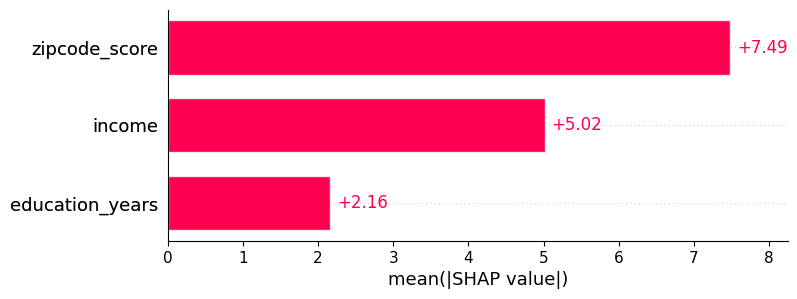

In [21]:
shap.plots.bar(shap_values)

### Import the `group` variable, which was **not** used in training this model.

In [22]:
X_test_with_group = X_test.copy()
X_test_with_group["group"] = df.loc[X_test.index, "group"]

### Look at the difference in SHAP values between the two groups across the variables used in the model.

In [23]:
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
shap_df["group"] = X_test_with_group["group"].values

shap_df.groupby("group").mean()

,income,education_years,zipcode_score
group,,,
0,1.086254,-0.170779,5.866534
1,1.020094,-0.192841,-6.859435


### Let's put `group` and `zipcode_score` in the same plot

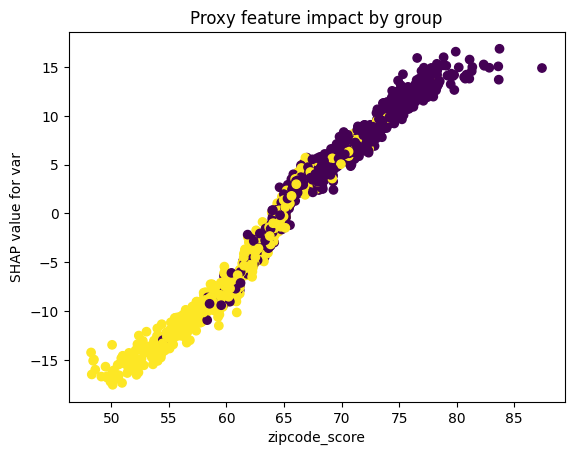

In [24]:
def plot_shap(var):
    # Extract SHAP values for the feature
    shap_var = shap_values[:, var].values

    # Plot the values of each group using different colors
    plt.figure()
    plt.scatter(
        X_test[var],
        shap_var,
        c=X_test_with_group["group"]
    )
    plt.xlabel(var)
    plt.ylabel(f"SHAP value for var")
    plt.title("Proxy feature impact by group")
    plt.show()

plot_shap("zipcode_score")

# Discussion Questions

### What is a _SHAP_ (or Shapley) value? 

A SHAP value measures how much a feature contributes to a model's prediction compared to the model's average prediction. A positive SHAP value means the feature increases the prediction, while a negative SHAP value means it decreases the prediction. The larger the absolute value, the greater the feature's impact on the prediction.

### Suppose you built this model and then it is peer reviewed by another entity. If the reviewer asks whether you used the variable `group` in your model, what would your answer be?

No, I did not use the group variable directly when training the model. The model was trained using income, education_years, and zipcode_score.

### If the reviewer asks whether the outcome of your model is correlated with `group`, what would your answer be?

Yes, there seems to be a connection between the model's predictions and group, even though group was not directly used in the model. The SHAP values for zipcode_score are very different between the two groups, which suggests that zipcode_score could be acting as a proxy for group and affecting the predictions differently for each group.

### Construct a "proxy feature impact by group" plot for `income`. How is this plot different from the one for `zipcode_score`?

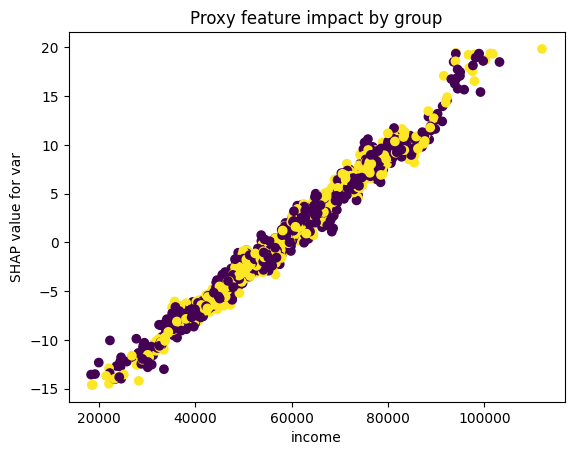

In [25]:
plot_shap("income")

The income plot shows the two groups more evenly distributed, with the yellow and purple points overlapping throughout the plot. In contrast, the zipcode_score plot shows more separation between the two groups, especially at higher and lower SHAP values. This suggests that zipcode_score has a more different impact on the model's predictions between the two groups than income does.

### If, instead, you were the **reviewer**, what other questions might you ask the person who built this model? Give at least two.

1. How was zipcode_score created, and is it associated with the group variable?
2. Did you test whether the model's predictions or errors differ between the two groups?